# Análisis Exploratorio de Datos (EDA) en Profundidad

En este cuaderno procesaremos toda la información de la carpeta `data` (incluyendo Laderas, Fracturas, RUSE e IMU) junto con las zonas_ageb_clean.

El objetivo es calcular:
1. Estadísticas Descriptivas (Tendencia Central y Dispersión).
2. Identificación de Valores Atípicos (Outliers).
3. Análisis de Correlación.
4. Visualización para definir qué aporta valor predictivo.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

# Para evitar alertas de pandas al ejecutar
import warnings
warnings.filterwarnings('ignore')

## 1. Carga de todos los datos disponibles

In [2]:
# Base limpiada en el paso anterior
ageb_clean = gpd.read_file('output/zonas_ageb_clean.geojson')

# Carga de archivos ignorados previamente en data/
ruse = pd.read_csv('data/registro-unico-de-situaciones-de-emergencia.csv', low_memory=False)
imu = pd.read_csv('data/imu_2020.csv')
laderas = pd.read_csv('data/atlas-de-riesgo-susceptibilidad-por-laderas.csv')
fracturas = gpd.read_file('data/Fracturas/SPC_Estructuras_Fracturas.shp')

print("✅ Datos cargados correctamente.")

✅ Datos cargados correctamente.


## 2. Medidas de Tendencia Central y de Dispersión

Extracción automática de:
- **Tendencia Central**: Media, Mediana (P50) y Moda.
- **Dispersión**: Desviación Estándar, Varianza, Rango y Percentiles (P25, P75).

In [3]:
def resumen_estadistico(df, nombre):
    numericas = df.select_dtypes(include=[np.number])
    if numericas.empty:
        return
    
    print(f"\n{'='*50}\n Resumen Estadístico: {nombre}\n{'='*50}")
    
    stats = numericas.describe().T
    
    # Añadimos la Mediana y Moda explícitamente
    stats['mediana'] = numericas.median()
    
    # Calcular moda (recuperando la primera ocurrencia por si hay bimodalidad)
    modas = numericas.mode()
    stats['moda'] = modas.iloc[0] if not modas.empty else np.nan
    
    # Varianza y rango
    stats['varianza'] = numericas.var()
    stats['rango'] = numericas.max() - numericas.min()
    
    # Ordenar y formatear columnas
    stats = stats[['mean', 'mediana', 'moda', 'std', 'varianza', 'rango', 'min', '25%', '50%', '75%', 'max']]
    stats.columns = ['Media', 'Mediana', 'Moda', 'Desviación_Std', 'Varianza', 'Rango', 'Mínimo', 'P25 (Q1)', 'P50 (Mediana)', 'P75 (Q3)', 'Máximo']
    
    display(stats.round(3))

# Ejecutamos la función sobre los conjuntos clave
resumen_estadistico(ageb_clean, "AGEB Clean (Zonas Base)")
resumen_estadistico(imu, "Marginación Social (IMU 2020)")
resumen_estadistico(laderas, "Susceptibilidad a Laderas (Derrumbes)")


 Resumen Estadístico: AGEB Clean (Zonas Base)


,Media,Mediana,Moda,Desviación_Std,Varianza,Rango,Mínimo,P25 (Q1),P50 (Mediana),P75 (Q3),Máximo
tipo_suelo,2.546000e+00,3.000000e+00,3.000000e+00,7.510000e-01,5.650000e-01,2.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00
area_total,7.319100e+08,6.681231e+08,6.681231e+08,3.131532e+08,9.806494e+16,1.095476e+09,2.979016e+08,6.681231e+08,6.681231e+08,6.681231e+08,1.393378e+09
riesgo_sismo,4.303000e+00,5.000000e+00,5.000000e+00,8.060000e-01,6.500000e-01,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00
riesgo_inundacion,4.267000e+00,5.000000e+00,5.000000e+00,1.383000e+00,1.913000e+00,4.000000e+00,1.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00
pct_afectacion_inundacion,3.800000e-02,3.200000e-02,9.600000e-02,2.500000e-02,1.000000e-03,9.500000e-02,1.000000e-03,1.800000e-02,3.200000e-02,4.900000e-02,9.600000e-02
suma_riesgos,8.570000e+00,9.000000e+00,1.000000e+01,2.030000e+00,4.121000e+00,6.000000e+00,4.000000e+00,8.000000e+00,9.000000e+00,1.000000e+01,1.000000e+01
riesgo_general,4.433000e+00,5.000000e+00,5.000000e+00,1.031000e+00,1.064000e+00,3.000000e+00,2.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00
area_total_norm,3.960000e-01,3.380000e-01,3.380000e-01,2.860000e-01,8.200000e-02,1.000000e+00,0.000000e+00,3.380000e-01,3.380000e-01,3.380000e-01,1.000000e+00
pct_afectacion_inundacion_norm,3.880000e-01,3.300000e-01,1.000000e+00,2.650000e-01,7.000000e-02,1.000000e+00,0.000000e+00,1.840000e-01,3.300000e-01,5.100000e-01,1.000000e+00



 Resumen Estadístico: Marginación Social (IMU 2020)


,Media,Mediana,Moda,Desviación_Std,Varianza,Rango,Mínimo,P25 (Q1),P50 (Mediana),P75 (Q3),Máximo
ENT,1.686600e+01,1.500000e+01,1.500000e+01,8.302000e+00,6.892400e+01,3.100000e+01,1.000000e+00,1.100000e+01,1.500000e+01,2.400000e+01,3.200000e+01
MUN,5.117100e+01,3.000000e+01,1.000000e+00,7.042600e+01,4.959752e+03,5.690000e+02,1.000000e+00,1.100000e+01,3.000000e+01,6.300000e+01,5.700000e+02
LOC,2.140400e+01,1.000000e+00,1.000000e+00,9.487700e+01,9.001728e+03,2.370000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.371000e+03
POB_TOTAL,1.947864e+03,1.512000e+03,9.200000e+01,1.799160e+03,3.236977e+06,2.904300e+04,2.200000e+01,6.080000e+02,1.512000e+03,2.749000e+03,2.906500e+04
P6A14NAE,5.684000e+00,4.627000e+00,0.000000e+00,4.890000e+00,2.391300e+01,8.095200e+01,0.000000e+00,2.721000e+00,4.627000e+00,7.336000e+00,8.095200e+01
SBASC,2.790200e+01,2.684600e+01,3.333300e+01,1.514500e+01,2.293700e+02,9.474000e+01,0.000000e+00,1.687600e+01,2.684600e+01,3.714200e+01,9.474000e+01
PSDSS,2.547800e+01,2.399200e+01,0.000000e+00,1.161900e+01,1.350030e+02,9.615400e+01,0.000000e+00,1.723300e+01,2.399200e+01,3.224500e+01,9.615400e+01
OVSDE,7.330000e-01,0.000000e+00,0.000000e+00,2.916000e+00,8.501000e+00,8.928600e+01,0.000000e+00,0.000000e+00,0.000000e+00,3.210000e-01,8.928600e+01
OVSEE,4.560000e-01,0.000000e+00,0.000000e+00,2.451000e+00,6.009000e+00,1.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.460000e-01,1.000000e+02
OVSAE,2.902000e+00,1.220000e-01,0.000000e+00,1.022300e+01,1.045090e+02,1.000000e+02,0.000000e+00,0.000000e+00,1.220000e-01,1.067000e+00,1.000000e+02



 Resumen Estadístico: Susceptibilidad a Laderas (Derrumbes)


,Media,Mediana,Moda,Desviación_Std,Varianza,Rango,Mínimo,P25 (Q1),P50 (Mediana),P75 (Q3),Máximo
id,1227.500,1227.500,1.000,708.481,5.019452e+05,2.453000e+03,1.000,614.000,1227.500,1841.000,2.454000e+03
area_m2,608571.512,233259.493,5990.912,4666699.002,2.177808e+13,1.638584e+08,5990.912,148794.756,233259.493,361328.904,1.638644e+08
perime_m,2918.119,2334.945,316.065,3868.163,1.496268e+07,1.138796e+05,316.065,1793.722,2334.945,3035.930,1.141957e+05
int2,1.348,1.000,1.000,0.910,8.280000e-01,4.000000e+00,1.000,1.000,1.000,1.000,5.000000e+00


## 3. Detección de Valores Atípicos (Outliers)
A través de Diagramas de Caja (Boxplots) observaremos visualmente las distancias al Rango Intercuartílico (IQR) e identificaremos observaciones atípicas extremas.

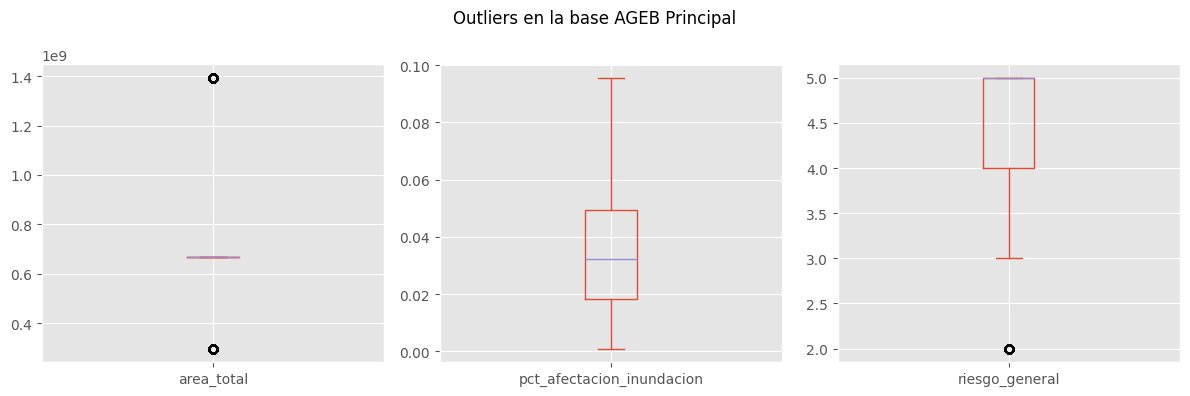

In [4]:
# Boxplots para AGEB
columnas_ag = [c for c in ['area_total', 'pct_afectacion_inundacion', 'riesgo_general'] if c in ageb_clean.columns]
if list(columnas_ag):
    ageb_clean[columnas_ag].plot(kind='box', subplots=True, layout=(1, len(columnas_ag)), figsize=(12, 4))
    plt.suptitle('Outliers en la base AGEB Principal')
    plt.tight_layout()
    plt.show()

# Boxplot para Indicador Socioeconómico (IMU)
columnas_imu = [c for c in ['IMU_2020', 'GRAPROES'] if c in imu.columns] # GRAPROES = Grado prom. escolaridad
if list(columnas_imu):
    imu[columnas_imu].plot(kind='box', subplots=True, figsize=(8, 4))
    plt.suptitle('Outliers en Marginación IMU')
    plt.tight_layout()
    plt.show()

## 4. Análisis de Correlación y Distribución
Un mapa de calor (Heatmap) nos devela la matriz de correlaciones (generalmente Pearson). ¿Qué variables están más fuertemente correlacionadas con el margen de riesgo?

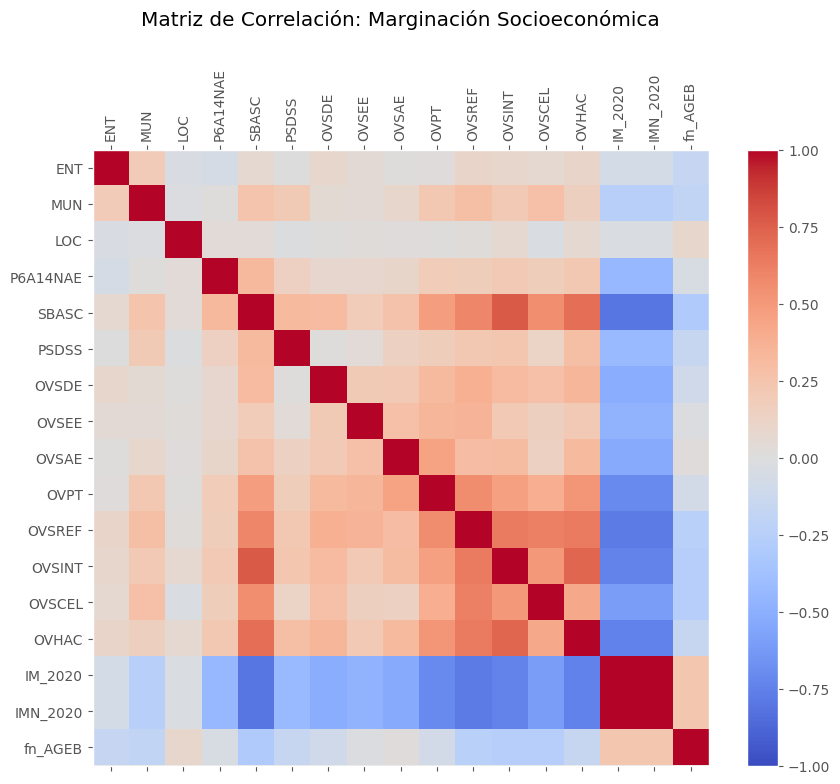

,ENT,MUN,LOC,P6A14NAE,SBASC,PSDSS,OVSDE,OVSEE,OVSAE,OVPT,OVSREF,OVSINT,OVSCEL,OVHAC,IM_2020,IMN_2020,fn_AGEB
ENT,1.000000,0.190000,-0.040000,-0.060000,0.060000,-0.010000,0.090000,0.040000,0.000000,0.010000,0.110000,0.090000,0.060000,0.110000,-0.070000,-0.070000,-0.170000
MUN,0.190000,1.000000,-0.020000,0.000000,0.240000,0.200000,0.050000,0.040000,0.090000,0.210000,0.290000,0.210000,0.280000,0.150000,-0.250000,-0.250000,-0.190000
LOC,-0.040000,-0.020000,1.000000,0.040000,0.040000,-0.010000,0.010000,0.020000,0.010000,0.000000,0.020000,0.060000,-0.030000,0.060000,-0.030000,-0.030000,0.090000
P6A14NAE,-0.060000,0.000000,0.040000,1.000000,0.330000,0.150000,0.080000,0.080000,0.100000,0.180000,0.180000,0.210000,0.170000,0.220000,-0.440000,-0.440000,-0.050000
SBASC,0.060000,0.240000,0.040000,0.330000,1.000000,0.310000,0.310000,0.190000,0.260000,0.470000,0.590000,0.770000,0.550000,0.690000,-0.800000,-0.800000,-0.290000
PSDSS,-0.010000,0.200000,-0.010000,0.150000,0.310000,1.000000,0.000000,0.040000,0.140000,0.180000,0.220000,0.230000,0.120000,0.280000,-0.420000,-0.420000,-0.160000
OVSDE,0.090000,0.050000,0.010000,0.080000,0.310000,0.000000,1.000000,0.200000,0.210000,0.320000,0.380000,0.310000,0.280000,0.340000,-0.510000,-0.510000,-0.100000
OVSEE,0.040000,0.040000,0.020000,0.080000,0.190000,0.040000,0.200000,1.000000,0.280000,0.340000,0.360000,0.210000,0.160000,0.210000,-0.470000,-0.470000,-0.020000
OVSAE,0.000000,0.090000,0.010000,0.100000,0.260000,0.140000,0.210000,0.280000,1.000000,0.450000,0.300000,0.300000,0.140000,0.320000,-0.520000,-0.520000,0.010000
OVPT,0.010000,0.210000,0.000000,0.180000,0.470000,0.180000,0.320000,0.340000,0.450000,1.000000,0.560000,0.460000,0.380000,0.510000,-0.700000,-0.700000,-0.080000


In [6]:
import subprocess
import sys

def matriz_correlacion(df, titulo):
    numericas = df.select_dtypes(include=[np.number])
    # Filtramos columnas que son simples identificadores (IDs, CVE)
    columnas_validas = [c for c in numericas.columns if not any(sub in c.upper() for sub in ['ID', 'OBJECT', 'CVE', 'POB_TOT'])]
    numericas = numericas[columnas_validas]
    
    if numericas.empty:
        return
        
    corr = numericas.corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    fig.colorbar(cax)
    
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.grid(False)
    plt.title(titulo, pad=30)
    plt.show()
    
    # Salida Tabular enriquecida (gradiente visual)
    display(corr.round(2).style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1))

subprocess.check_call([sys.executable, "-m", "pip", "install", "jinja2"])
matriz_correlacion(imu, "Matriz de Correlación: Marginación Socioeconómica")

## 5. Cruces Espaciales Descriptivos (Vista rápida)
El último test descriptivo es poner los conjuntos adicionales no tabulados (como Fracturas y Siniestros Reales de RUSE) unos contra otros para verificar si están aportando información distribuida geográficamente.

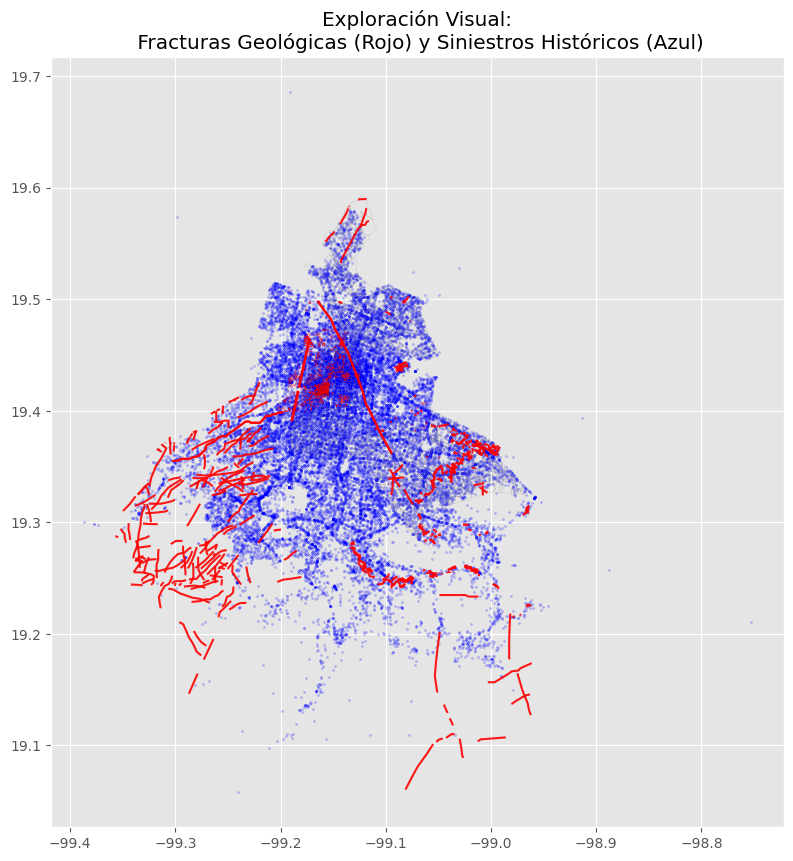

In [8]:
pd.options.mode.chained_assignment = None

# Identificar columnas de coordenadas usando nombres esperados en RUSE
columnas_normalizadas = {c.lower().strip(): c for c in ruse.columns}
col_lon = next((columnas_normalizadas[c] for c in ['longitud', 'longitude', 'lon', 'lng'] if c in columnas_normalizadas), None)
col_lat = next((columnas_normalizadas[c] for c in ['latitud', 'latitude', 'lat'] if c in columnas_normalizadas), None)

if col_lon and col_lat:
    ruse_gps = ruse.copy()
    ruse_gps[col_lon] = pd.to_numeric(ruse_gps[col_lon], errors='coerce')
    ruse_gps[col_lat] = pd.to_numeric(ruse_gps[col_lat], errors='coerce')
    ruse_gps = ruse_gps.dropna(subset=[col_lon, col_lat])
    
    # Filtramos atípicos globales (coordenadas erróneas fuera de CDMX)
    ruse_gps = ruse_gps[(ruse_gps[col_lon] > -100) & (ruse_gps[col_lon] < -98)]
    ruse_gps = ruse_gps[(ruse_gps[col_lat] > 19) & (ruse_gps[col_lat] < 20)]
    
    # Convertir RUSE en mapa geográfico
    ruse_gdf = gpd.GeoDataFrame(
        ruse_gps, 
        geometry=gpd.points_from_xy(ruse_gps[col_lon], ruse_gps[col_lat]), 
        crs="EPSG:4326"
    )
    
    # Dibujando
    fig, ax = plt.subplots(figsize=(10, 10))
    ageb_clean.to_crs("EPSG:4326").boundary.plot(ax=ax, linewidth=0.2, color='gray', alpha=0.5, label='AGEB')
    fracturas.to_crs("EPSG:4326").plot(ax=ax, color='red', linewidth=1.5, alpha=0.9, label='Fracturas')
    ruse_gdf.plot(ax=ax, color='blue', markersize=2, alpha=0.2, label='Emergencia RUSE')
    
    plt.title("Exploración Visual:\n Fracturas Geológicas (Rojo) y Siniestros Históricos (Azul)")
    plt.show()
else:
    print("El dataset RUSE no tiene información directa de coordenadas con nombres estandar.")